# Skin Lesion Segmentation

---  
## 1. Khởi tạo môi trường và cố định seed

In [2]:
import os
import math
import random
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR

import warnings
warnings.filterwarnings('ignore')

import wandb

# Kiểm tra phiên bản và thiết bị phần cứng
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()} (Device: {device})")
print(f"W&B Version     : {wandb.__version__}")

# Hàm cố định Seed để đảm bảo tính tái lập (Reproducibility)
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Đã cố định Random Seed = 42")


PyTorch Version : 2.7.1+cu118
CUDA Available  : True (Device: cuda)
W&B Version     : 0.29.0
Đã cố định Random Seed = 42


---  
## 2. Xác thực tài khoản Weights & Biases

In [3]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\PC MSI\_netrc.
wandb: Currently logged in as: vubaonguyen2809 (vubaonguyen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

---  
## 3. Chuẩn bị dữ liệu và data augmentation

Dữ liệu đã được tiền xử lý và lưu dưới dạng các file numpy (`.npy`) giúp nạp toàn bộ vào RAM để tăng tốc độ huấn luyện tối đa.

### 3.1. Các hàm data augmentation

In [4]:
def color_jitter(img: np.ndarray) -> np.ndarray:
    """Điều chỉnh ngẫu nhiên độ sáng, độ tương phản và sắc độ (Hue/Saturation)."""
    # 1. Brightness & Contrast
    alpha = random.uniform(0.8, 1.2)   # Contrast
    beta = random.uniform(-20, 20)     # Brightness
    img = np.clip(alpha * img.astype(float) + beta, 0, 255).astype(np.uint8)

    # 2. Saturation & Hue trong không gian HSV
    if random.random() > 0.5:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(float)
        hsv[:, :, 0] = (hsv[:, :, 0] + random.uniform(-10, 10)) % 180  # Hue
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.8, 1.2), 0, 255)  # Saturation
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    return img

In [5]:
def random_rotate_and_crop(img: np.ndarray, mask: np.ndarray, img_size=(256, 256)):
    """Xoay tự do góc (-45 đến +45 độ) và Random Crop & Resize đồng bộ."""
    h, w = img_size
    # Random Rotate
    if random.random() > 0.5:
        angle = random.uniform(-45, 45)
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)

    # Random Crop & Resize
    if random.random() > 0.5:
        scale = random.uniform(0.8, 1.0)
        new_h, new_w = int(h * scale), int(w * scale)
        top = random.randint(0, h - new_h)
        left = random.randint(0, w - new_w)
        
        img = img[top:top + new_h, left:left + new_w]
        mask = mask[top:top + new_h, left:left + new_w]

        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    return img, mask

In [6]:
def apply_augmentations(img: np.ndarray, mask: np.ndarray):
    """Tổng hợp toàn bộ các phép biến đổi data augmentation khi training."""
    # 1. Horizontal Flip
    if random.random() > 0.5:
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()

    # 2. Vertical Flip
    if random.random() > 0.5:
        img = np.flipud(img).copy()
        mask = np.flipud(mask).copy()

    # 3. Transpose (Đổi trục X, Y)
    if random.random() > 0.5:
        img = np.transpose(img, (1, 0, 2)).copy()
        mask = np.transpose(mask, (1, 0)).copy()

    # 4. Random 90-degree Rotation
    k = random.choice([0, 1, 2, 3])
    if k > 0:
        img = np.rot90(img, k, (0, 1)).copy()
        mask = np.rot90(mask, k, (0, 1)).copy()

    # 5. Rotation tự do & Random Cropping
    img, mask = random_rotate_and_crop(img, mask)

    # 6. Color Jitter (Chỉ áp dụng lên ảnh)
    if random.random() > 0.5:
        img = color_jitter(img)

    return img, mask

### 3.2. Dataset và dataloader

In [7]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "2"

class FastSkinDataset(Dataset):
    """Dataset nạp sẵn dữ liệu vào RAM để tối ưu tốc độ đọc đĩa."""
    def __init__(self, data_dir, is_train=False):
        self.is_train = is_train

        images_path = os.path.join(data_dir, "images.npy")
        masks_path = os.path.join(data_dir, "masks.npy")
        ids_path = os.path.join(data_dir, "image_ids.npy")

        self.images = np.load(images_path)
        self.masks = np.load(masks_path) if os.path.exists(masks_path) else None
        self.image_ids = np.load(ids_path) if os.path.exists(ids_path) else None

        # Mean & Std chuẩn ImageNet
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        if self.masks is not None:
            mask = self.masks[idx]

            # Áp dụng Augmentation khi Training
            if self.is_train:
                image, mask = apply_augmentations(image, mask)

            # Chuẩn hóa ảnh: (H, W, 3) -> (3, H, W) [0, 1] và trừ Mean/Std
            image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
            image = torch.from_numpy(image).permute(2, 0, 1).float()
            mask = torch.from_numpy(mask).float().unsqueeze(0)

            return image, mask

        # Test Inference (không có mask)
        image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        sample_id = self.image_ids[idx] if self.image_ids is not None else str(idx)
        return image, sample_id


def get_dataloaders(processed_base=DATA_DIR, batch_size=16, num_workers=0):
    """Tạo DataLoaders cho các tập Train, Validation và Test."""
    train_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "train_256"), is_train=True),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=True
    )

    val_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "val_256"), is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )

    test_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "test_256"), is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )

    return train_loader, val_loader, test_loader

### 3.3. Trực quan hoá mẫu dữ liệu từ dataloader

Images Shape       : torch.Size([16, 3, 256, 256]) (dtype: torch.float32)
Masks Shape        : torch.Size([16, 1, 256, 256]) (dtype: torch.float32)
Mask Unique Values : [0.0, 1.0]


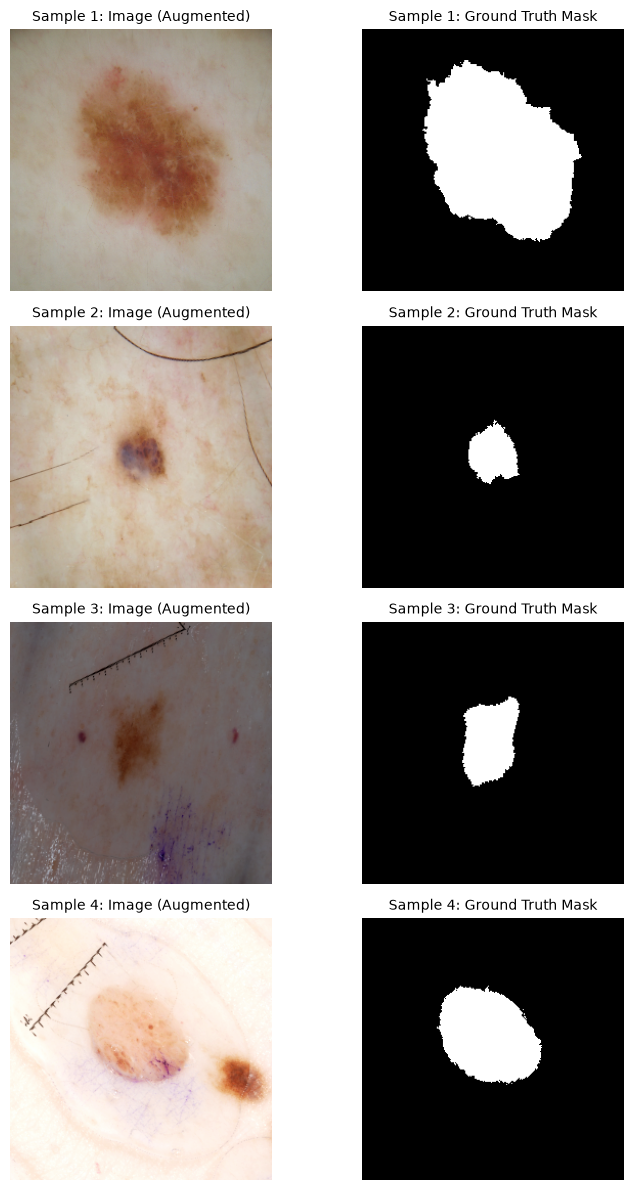

In [29]:
train_loader, val_loader, _ = get_dataloaders(batch_size=16, num_workers=0)
sample_images, sample_masks = next(iter(train_loader))

print(f"Images Shape       : {sample_images.shape} (dtype: {sample_images.dtype})")
print(f"Masks Shape        : {sample_masks.shape} (dtype: {sample_masks.dtype})")
print(f"Mask Unique Values : {torch.unique(sample_masks).tolist()}")

# Vẽ 4 mẫu ảnh và mask tương ứng
fig, axes = plt.subplots(4, 2, figsize=(8, 12))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(4):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)
    mask = sample_masks[i, 0].numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Sample {i+1}: Image (Augmented)", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask", fontsize=10)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

---  
## 4. Kiến trúc Mô hình

Lựa chọn kiến trúc **UNet** làm baseline:


In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, bilinear=True):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

---  
## 5. Loss Function And Evaluation Metrics

In [31]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred: torch.Tensor, target: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:
    """Soft Dice Loss hỗ trợ tính gradient trực tiếp."""
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return 1.0 - dice.mean()


def combined_loss(pred: torch.Tensor, target: torch.Tensor, alpha: float = 0.5) -> torch.Tensor:
    """Kết hợp BCEWithLogitsLoss và DiceLoss."""
    return alpha * bce_loss(pred, target) + (1.0 - alpha) * dice_loss(pred, target)


def dice_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, smooth: float = 1e-6) -> float:
    """Tính Dice Coefficient cho batch dữ liệu."""
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return dice.mean().item()

---  
## 6. Callbacks và trực quan hóa

In [51]:
class EarlyStopping:
    """Dừng sớm nếu metric theo dõi không cải thiện sau `patience` epochs."""
    def __init__(self, patience=5, min_delta=1e-4, mode="max", save_path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.save_path = save_path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_metric = -float("inf") if mode == "max" else float("inf")

    def __call__(self, current_metric, model, epoch=None, optimizer=None):
        score = current_metric if self.mode == "max" else -current_metric

        if self.best_score is None:
            self.best_score = score
            self.best_metric = current_metric
            self.save_checkpoint(epoch, model, optimizer)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_metric = current_metric
            self.save_checkpoint(epoch, model, optimizer) 
            self.counter = 0

    def save_checkpoint(self, epoch, model, optimizer):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_metric": self.best_metric,
        }
        torch.save(checkpoint, self.save_path)

In [52]:
def log_predictions_to_wandb(samples, current_epoch, num_samples=4):
    """
    Tạo 1 ảnh tổng hợp so sánh trực quan 3 cột:
    Cột 1: Ảnh gốc | Cột 2: Ground Truth Mask | Cột 3: Model Prediction
    """
    images, masks, preds = samples
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3.5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        # 1. Un-normalize ảnh RGB
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip((img * std + mean), 0, 1)

        # 2. Lấy mask 2D
        gt = masks[i].squeeze().numpy()
        pred = preds[i].squeeze().numpy()

        # Cột 1: Ảnh gốc
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1}: Input Image", fontsize=11, fontweight="bold")
        axes[i, 0].axis("off")

        # Cột 2: Ground Truth
        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask", fontsize=11, color="green", fontweight="bold")
        axes[i, 1].axis("off")

        # Cột 3: Prediction
        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Sample {i+1}: Model Prediction", fontsize=11, color="blue", fontweight="bold")
        axes[i, 2].axis("off")

    plt.suptitle(f"--- VALIDATION PREDICTIONS (EPOCH {current_epoch}) ---", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    # 1. Log ảnh bảng so sánh này lên W&B
    wandb.log({"val/visual_comparison": wandb.Image(fig)}, step=current_epoch)

    # 2. Hiển thị trực tiếp trong Notebook
    plt.show()
    plt.close(fig)

---  
## 7. Huấn luyện và đánh giá

In [53]:
def train_one_epoch(model, loader, optimizer, device, current_epoch, criterion=combined_loss):
    """Huấn luyện mô hình trong 1 epoch"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    num_batches = len(loader)

    pbar = tqdm(enumerate(loader), total=num_batches, desc=f"Train Epoch {current_epoch+1}", leave=False)

    for batch_idx, (images, masks) in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # 1. Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)

        # 2. Backward pass và cập nhật trọng số
        loss.backward()
        optimizer.step()

        # 3. Tính toán thống kê
        batch_size = images.size(0)
        batch_loss = loss.item()
        batch_dice = dice_score(outputs.detach(), masks)

        running_loss += batch_loss * batch_size
        running_dice += batch_dice * batch_size

        current_lr = optimizer.param_groups[0]["lr"]
        pbar.set_postfix({"loss": f"{batch_loss:.4f}", "dice": f"{batch_dice:.4f}", "lr": f"{current_lr:.2e}"})

        # 4. Ghi log step-level định kỳ trên W&B
        global_step = current_epoch * num_batches + batch_idx
        if batch_idx % 10 == 0:
            wandb.log({
                "train/step_loss": batch_loss,
                "train/step_dice": batch_dice,
                "train/learning_rate": current_lr,
            }, step=global_step)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_dice = running_dice / len(loader.dataset)
    return epoch_loss, epoch_dice

In [54]:
@torch.no_grad()
def validate_one_epoch(model, loader, device, current_epoch, criterion=combined_loss):
    """Đánh giá mô hình trên tập validation và trích xuất mẫu dự đoán."""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    val_samples = None

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Val Epoch {current_epoch+1}", leave=False)

    for batch_idx, (images, masks) in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, masks)

        batch_size = images.size(0)
        batch_loss = loss.item()
        batch_dice = dice_score(outputs, masks)

        running_loss += batch_loss * batch_size
        running_dice += batch_dice * batch_size

        pbar.set_postfix({"val_loss": f"{batch_loss:.4f}", "val_dice": f"{batch_dice:.4f}"})

        # Lưu batch đầu tiên để visualize
        if batch_idx == 0:
            val_samples = (
                images.cpu(),
                masks.cpu(),
                (torch.sigmoid(outputs) > 0.5).float().cpu()
            )

    epoch_loss = running_loss / len(loader.dataset)
    epoch_dice = running_dice / len(loader.dataset)
    return epoch_loss, epoch_dice, val_samples


In [55]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    epochs=30,
    patience=5,
    criterion=combined_loss,
    save_dir="../checkpoints"
):
    """Toàn bộ vòng lặp huấn luyện, đánh giá, scheduler, earlystopping"""
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_model.pth")
    
    early_stopping = EarlyStopping(patience=patience, mode="max", save_path=best_model_path)
    total_start_time = time.time()

    print(f"Bắt đầu huấn luyện trên thiết bị: {device} ({epochs} Epochs | Patience: {patience})")
    print("=" * 75)

    for epoch in range(epochs):
        epoch_start_time = time.time()

        # 1. Huấn luyện 1 Epoch
        train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, device, epoch, criterion)

        # 2. Đánh giá 1 Epoch
        val_loss, val_dice, val_samples = validate_one_epoch(model, val_loader, device, epoch, criterion)

        # 3. Cập nhật Learning Rate Scheduler
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_duration = time.time() - epoch_start_time

        # 4. In thông tin Epoch
        print(
            f"Epoch [{epoch+1:02d}/{epochs:02d}] ({epoch_duration:.1f}s) | "
            f"Train Loss: {train_loss:.4f} - Dice: {train_dice:.4f} | "
            f"Val Loss: {val_loss:.4f} - Dice: {val_dice:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # 5. Log Epoch-level metrics lên W&B
        wandb.log({
            "epoch": epoch + 1,
            "train/epoch_loss": train_loss,
            "train/epoch_dice": train_dice,
            "val/epoch_loss": val_loss,
            "val/epoch_dice": val_dice,
            "epoch/learning_rate": current_lr,
        })

        # 6. Kiểm tra early stopping và lưu best model
        early_stopping(val_dice, model, epoch=epoch+1, optimizer=optimizer)
        if early_stopping.early_stop:
            print(f"\nDỪNG SỚM (Early Stopping) tại Epoch {epoch+1}! Metric không tăng sau {patience} epochs.")
            wandb.run.summary["early_stopped_epoch"] = epoch + 1
            break

    # 7. Log hình ảnh dự đoán ở epoch cuối
    log_predictions_to_wandb(val_samples, current_epoch=epoch+1)

    # Ghi nhận kết quả tốt nhất lên W&B Summary
    wandb.run.summary["best_val_dice"] = early_stopping.best_metric
    total_time = time.time() - total_start_time
    print("=" * 75)
    print(f"Hoàn thành huấn luyện trong {total_time/60:.2f} phút. Best Val Dice: {early_stopping.best_metric:.4f}")

---  
## 8. Thực thi huấn luyện 

### 8.1. Cấu hình thực nghiệm và tạo run trên W&B

In [56]:
config = {
    "architecture": "UNet",
    "dataset": "ISIC-256",
    "image_size": 256,
    "batch_size": 16,
    "epochs": 20,                       
    "patience": 4,                     
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
}

In [57]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d-%H%M")
name = f"unet-isic2018-baseline-lr1e-3-bs16-epoch20-{timestamp}" 
notes = """
aug: color-jitter, random_rotate, random transpose, random H,V Flip.
img: 256,
baseline
"""

# 1. Khởi tạo W&B Run
run = wandb.init(
    project="skin-lesion-segmentation",
    group="architecture",
    job_type="training",
    tags=["unet", "isic2018", "baseline"],
    notes=notes, 
    name=name,
    config=config,
)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁█
epoch/learning_rate,█▁
train/epoch_dice,▁█
train/epoch_loss,█▁
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁
train/step_dice,▁▃█▇█▅▇▅▇█▅█
train/step_loss,█▇▁▂▁▆▂█▂▂▄▃
val/epoch_dice,▁█
val/epoch_loss,█▁
epoch,2
epoch/learning_rate,0.00098


In [58]:
# 2. Chuẩn bị Dataloaders
train_loader, val_loader, test_loader = get_dataloaders(batch_size=config["batch_size"], num_workers=0)

In [59]:
# 3. Khởi tạo mô hình 
model = UNet(n_channels=3, n_classes=1, bilinear=True).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Khởi tạo {config['architecture']} thành công | Tổng số tham số: {total_params:,}")

Khởi tạo UNet thành công | Tổng số tham số: 13,391,361


In [60]:
# 4. Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=config["epochs"], eta_min=1e-5)

In [ ]:
# 5. Huấn luyện
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=config["epochs"],
    patience=config["patience"],
    save_dir="./checkpoints"
)

Bắt đầu huấn luyện trên thiết bị: cuda (20 Epochs | Patience: 4)


Train Epoch 1:  61%|██████    | 69/113 [06:20<04:10,  5.70s/it, loss=0.3943, dice=0.7139, lr=1.00e-03]

## 9. Testing 

In [ ]:
def log_model_to_wandb(model_path, model_name="UNet", config_dict=None):
    if not os.path.exists(model_path):
        print(f"Không tìm thấy checkpoint tại: {model_path}")
        return

    ckpt = torch.load(model_path, map_location="cpu")
    best_val_dice = ckpt.get("best_metric", 0.0) if isinstance(ckpt, dict) else 0.0

    artifact = wandb.Artifact(
        name=f"skin-lesion-{model_name.lower()}",
        type="model",
        description=f"Best checkpoint for {model_name} on ISIC 2018 dataset",
        metadata={
            "architecture": model_name,
            "best_val_dice": round(float(best_val_dice), 4),
            "config": config_dict or {},
        },
    )
    
    artifact.add_file(model_path)
    wandb.log_artifact(artifact, aliases=["latest","best"])
    print(f"Đã lưu Model Artifact lên W&B thành công (Best Val Dice: {best_val_dice:.4f})!")

In [ ]:
def compute_all_metrics(pred_mask, gt_mask, smooth=1e-6):
    pred = (pred_mask > 0).astype(np.float32)
    gt = (gt_mask > 0).astype(np.float32)

    TP = (pred * gt).sum()
    FP = (pred * (1.0 - gt)).sum()
    FN = ((1.0 - pred) * gt).sum()
    TN = ((1.0 - pred) * (1.0 - gt)).sum()

    dice = (2.0 * TP + smooth) / (2.0 * TP + FP + FN + smooth)
    iou = (TP + smooth) / (TP + FP + FN + smooth)
    sensitivity = (TP + smooth) / (TP + FN + smooth)
    specificity = (TN + smooth) / (TN + FP + smooth)
    precision = (TP + smooth) / (TP + FP + smooth)
    accuracy = (TP + TN + smooth) / (TP + TN + FP + FN + smooth)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "accuracy": float(accuracy),
    }


def evaluate_test_full_metrics(
    model, test_loader, model_path, device, num_visualize=20
):
    print(f"\n=======================================================")
    print(f"BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST VỚI BEST CHECKPOINT")
    print(f"=======================================================")

    # 1. Nạp trọng số tốt nhất
    ckpt = torch.load(model_path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif isinstance(ckpt, dict):
        model.load_state_dict(ckpt)
    model.eval()

    # 2. Bảng W&B lưu đầy đủ các chỉ số
    test_table = wandb.Table(
        columns=[
            "Sample_ID",
            "Visual_Overlay",
            "Ground_Truth",
            "Prediction",
            "Dice",
            "IoU",
            "Sensitivity (Recall)",
            "Specificity",
            "Precision",
        ]
    )

    # Bộ tích lũy điểm
    metrics_sum = {
        "dice": 0.0,
        "iou": 0.0,
        "sensitivity": 0.0,
        "specificity": 0.0,
        "precision": 0.0,
        "accuracy": 0.0,
    }

    sample_count = 0
    logged_count = 0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    with torch.no_grad():
        for batch_data in tqdm(test_loader, desc="[Testing Full Metrics]"):
            if (
                isinstance(batch_data, (list, tuple))
                and len(batch_data) == 2
                and isinstance(batch_data[1], torch.Tensor)
            ):
                images, masks = batch_data[0].to(device), batch_data[1].to(device)
                has_gt = True
            else:
                images = (
                    batch_data[0].to(device)
                    if isinstance(batch_data, (list, tuple))
                    else batch_data.to(device)
                )
                masks = None
                has_gt = False

            logits = model(images)
            preds = (torch.sigmoid(logits) > 0.5).float()

            for b in range(images.size(0)):
                img_np = images[b].cpu().permute(1, 2, 0).numpy()
                img_orig = np.clip((img_np * std + mean) * 255.0, 0, 255).astype(
                    np.uint8
                )
                pred_np = preds[b, 0].cpu().numpy().astype(np.uint8)

                if has_gt:
                    gt_np = masks[b, 0].cpu().numpy().astype(np.uint8)
                    m = compute_all_metrics(pred_np, gt_np)
                else:
                    gt_np = np.zeros_like(pred_np)
                    m = {k: 0.0 for k in metrics_sum}
                for k in metrics_sum:
                    metrics_sum[k] += m[k]
                sample_count += 1

                # Log trực quan hóa
                if logged_count < num_visualize:
                    masks_dict = {
                        "predictions": {
                            "mask_data": pred_np,
                            "class_labels": {1: "Lesion"},
                        }
                    }
                    if has_gt:
                        masks_dict["ground_truth"] = {
                            "mask_data": gt_np,
                            "class_labels": {1: "Lesion"},
                        }
                    overlay_image = wandb.Image(img_orig, masks=masks_dict)
                    test_table.add_data(
                        f"test_sample_{sample_count}",
                        overlay_image,
                        wandb.Image(gt_np * 255),
                        wandb.Image(pred_np * 255),
                        round(m["dice"], 4),
                        round(m["iou"], 4),
                        round(m["sensitivity"], 4),
                        round(m["specificity"], 4),
                        round(m["precision"], 4),
                    )
                    logged_count += 1
    # 3. Tính trung bình các chỉ số
    final_results = {
        f"test/{k}": round(v / max(sample_count, 1), 4) for k, v in metrics_sum.items()
    }
    # 4. Ghi tất cả vào W&B Summary và Dashboard
    for k, v in final_results.items():
        wandb.summary[k] = v
    wandb.log({"test/predictions_table": test_table, **final_results})
    
    print(f"\n=======================================================")
    print(f"KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ CHỈ SỐ TRÊN TẬP TEST:")
    print(f"   Dice Score (F1)    : {final_results['test/dice']:.4f}")
    print(f"   IoU (Jaccard)      : {final_results['test/iou']:.4f}")
    print(f"   Sensitivity/Recall : {final_results['test/sensitivity']:.4f}  (Khả năng bắt trọn bệnh)")
    print(f"   Specificity        : {final_results['test/specificity']:.4f}  (Nhận diện da lành)")
    print(f"   Precision          : {final_results['test/precision']:.4f}")
    print(f"   Pixel Accuracy     : {final_results['test/accuracy']:.4f}")
    print(f"   Tổng số mẫu test   : {sample_count}")
    print(f"=======================================================")

In [ ]:
checkpoint_file = "./checkpoints/best_model.pth"
# 1. Upload Model Checkpoint lên W&B Artifacts
log_model_to_wandb(
    model_path=checkpoint_file,
    model_name="UNet",
    config_dict=config if "config" in locals() else {"batch_size": 16, "image_size": 256}
)
# 2. Tiến hành chạy Test toàn diện
evaluate_test_full_metrics(
    model=model,
    test_loader=test_loader,
    model_path=checkpoint_file,
    device=device,
    num_visualize=20  # Số ảnh muốn trực quan hóa trên W&B
)

In [ ]:
# 6. Đóng W&B Run
wandb.finish()
print("✅ Hoàn tất thử nghiệm W&B!")